In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Trader Performance vs Market Sentiment Analysis

## Objective
This project analyzes how Bitcoin market sentiment (Fear vs Greed) affects trader behavior and performance on Hyperliquid.

The analysis focuses on:
- Trader profitability
- Trading activity
- Leverage behavior
- Risk-taking patterns
- Behavioral segmentation

Goal:
Identify actionable insights and trading strategies using sentiment-driven behavioral analysis.

## Data Loading

The datasets were loaded into pandas DataFrames for preprocessing and analysis.

Datasets used:
1. Bitcoin Fear & Greed Index
2. Hyperliquid Historical Trader Data

In [5]:
sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

In [6]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Initial Data Inspection

The datasets are inspected to understand:
- dataset dimensions
- column structure
- data types
- missing values
- duplicate records

### Dataset Shapes

Checking the number of rows and columns in each dataset.

In [8]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (51122, 16)


### Missing Value Analysis

Checking whether datasets contain missing or incomplete records.

In [9]:
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [10]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


### Duplicate Record Analysis

Checking for duplicate rows that may affect analysis accuracy.

In [11]:
print("Sentiment Duplicates:", sentiment.duplicated().sum())
print("Trades Duplicates:", trades.duplicated().sum())

Sentiment Duplicates: 0
Trades Duplicates: 0


### Date Conversion and Alignment

The sentiment dataset and trade dataset use different timestamp formats.

To combine both datasets effectively, timestamps are converted into a common daily date format.

In [12]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [13]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

### Creating Common Date Format

To align both datasets accurately, timestamps are converted into a common daily date format.

This enables daily-level sentiment analysis of trading activity and trader performance.

In [14]:
trades['date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = sentiment['date'].dt.date

### Merging Sentiment with Trade Data

The datasets are merged on the daily date field so that each trade record is associated with the corresponding market sentiment classification.

In [15]:
merged = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [16]:
merged[['Timestamp IST', 'classification']].head()

,Timestamp IST,classification
0,2024-12-02 22:50:00,Extreme Greed
1,2024-12-02 22:50:00,Extreme Greed
2,2024-12-02 22:50:00,Extreme Greed
3,2024-12-02 22:50:00,Extreme Greed
4,2024-12-02 22:50:00,Extreme Greed


### Sentiment Distribution

Analyzing the frequency of different market sentiment conditions present in the merged dataset.

In [17]:
merged['classification'].value_counts()

,count
classification,
Greed,16373
Fear,12688
Neutral,10462
Extreme Greed,9708
Extreme Fear,1885


### Profitability Indicator

Creating a binary profitability flag to identify whether individual trades resulted in profit or loss.


In [18]:
merged['is_profit'] = merged['Closed PnL'] > 0

### Summary Statistics

Generating descriptive statistics for key numerical variables related to profitability, trade size, and transaction costs.

In [19]:
merged[['Closed PnL', 'Size USD', 'Fee']].describe()

,Closed PnL,Size USD,Fee
count,51122.000000,5.112200e+04,51121.000000
mean,122.769454,1.392361e+04,2.876620
std,1593.418930,6.873653e+04,11.969882
min,-117990.104100,0.000000e+00,-1.175712
25%,0.000000,2.921325e+02,0.017428
50%,0.000000,1.197020e+03,0.192114
75%,17.978180,7.542510e+03,1.515279
max,135329.090100,3.921431e+06,837.471593


In [20]:
merged['classification'].value_counts()

,count
classification,
Greed,16373
Fear,12688
Neutral,10462
Extreme Greed,9708
Extreme Fear,1885


## Feature Engineering

In this section, additional analytical features are created to measure:
- trader profitability
- trading activity
- trade direction
- trader behavior patterns

These features will support sentiment-based performance analysis and trader segmentation.

### Trade Direction Features

Creating directional indicators to analyze long and short trading behavior across market sentiment conditions.

In [21]:
merged['is_long'] = merged['Side'] == 'BUY'

### Daily Trader Metrics

Aggregating trade-level records into daily trader-level metrics to analyze profitability, trading behavior, and activity patterns.

In [22]:
daily_metrics = merged.groupby(
    ['Account', 'date', 'classification']
).agg({
    'Closed PnL': 'sum',
    'Size USD': 'mean',
    'Fee': 'mean',
    'is_profit': 'mean',
    'Trade ID': 'count',
    'is_long': 'mean'
}).reset_index()

### Renaming Aggregated Features

Renaming aggregated columns into cleaner analytical feature names for easier interpretation.

In [23]:
daily_metrics.rename(columns={
    'Closed PnL': 'daily_pnl',
    'Size USD': 'avg_trade_size',
    'Fee': 'avg_fee',
    'is_profit': 'win_rate',
    'Trade ID': 'trade_count',
    'is_long': 'long_ratio'
}, inplace=True)

### Daily Metrics Preview

Previewing the transformed trader-level analytical dataset.

In [24]:
daily_metrics.head()

,Account,date,classification,daily_pnl,avg_trade_size,avg_fee,win_rate,trade_count,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,5089.718249,0.948000,0.000000,177,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,7976.664412,0.998288,0.000000,68,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,23734.500000,2.373450,0.000000,40,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,28186.666667,2.818666,0.000000,12,1.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,17248.148148,3.874907,0.444444,27,0.444444


### Trader Activity Segmentation

Classifying traders based on trading frequency to compare behavior between high-activity and low-activity participants.

In [25]:
median_trades = daily_metrics['trade_count'].median()

daily_metrics['trader_activity'] = np.where(
    daily_metrics['trade_count'] > median_trades,
    'High Activity',
    'Low Activity'
)

### Profitability Classification

Classifying trader-days into profitable and loss-making categories based on daily realized PnL.

In [26]:
daily_metrics['pnl_category'] = np.where(
    daily_metrics['daily_pnl'] > 0,
    'Profitable',
    'Non-Profitable'
)

### Final Analytical Dataset Summary

Reviewing the structure and statistical properties of the engineered analytical dataset.

In [27]:
daily_metrics.head()

,Account,date,classification,daily_pnl,avg_trade_size,avg_fee,win_rate,trade_count,long_ratio,trader_activity,pnl_category
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0,5089.718249,0.948000,0.000000,177,0.000000,High Activity,Non-Profitable
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0,7976.664412,0.998288,0.000000,68,0.000000,High Activity,Non-Profitable
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0,23734.500000,2.373450,0.000000,40,0.000000,High Activity,Non-Profitable
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0,28186.666667,2.818666,0.000000,12,1.000000,Low Activity,Non-Profitable
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1,17248.148148,3.874907,0.444444,27,0.444444,High Activity,Profitable


In [28]:
daily_metrics.describe()

,daily_pnl,avg_trade_size,avg_fee,win_rate,trade_count,long_ratio
count,941.000000,941.000000,941.000000,941.000000,941.000000,941.000000
mean,6624.599415,10089.947115,2.657285,0.351674,54.319872,0.529456
std,35613.906047,14163.014767,3.327866,0.367240,116.051340,0.391266
min,-175611.000056,0.100000,-0.092558,0.000000,1.000000,0.000000
25%,0.000000,1881.207605,0.284468,0.000000,8.000000,0.090909
50%,228.579840,5318.463636,1.389051,0.258065,20.000000,0.538462
75%,2390.123350,13735.521525,4.023782,0.666667,52.000000,1.000000
max,533974.662903,185847.000000,28.631983,1.000000,1251.000000,1.000000


The provided dataset did not contain an explicit leverage field. Therefore, trade size and trading activity were used as proxies for trader risk exposure.

## Performance Analysis by Market Sentiment

This section analyzes how trader profitability, trading activity, trade sizing, and directional behavior vary across different market sentiment conditions.

The analysis focuses on identifying behavioral and performance changes during:
- Fear
- Extreme Fear
- Neutral
- Greed
- Extreme Greed

### Average Daily Profitability by Sentiment

Analyzing whether trader profitability changes across different market sentiment regimes.

In [29]:
sentiment_pnl = daily_metrics.groupby(
    'classification'
)['daily_pnl'].mean().reset_index()

sentiment_pnl

,classification,daily_pnl
0,Extreme Fear,8958.430263
1,Extreme Greed,6789.443007
2,Fear,9426.390311
3,Greed,4659.146941
4,Neutral,6367.769082


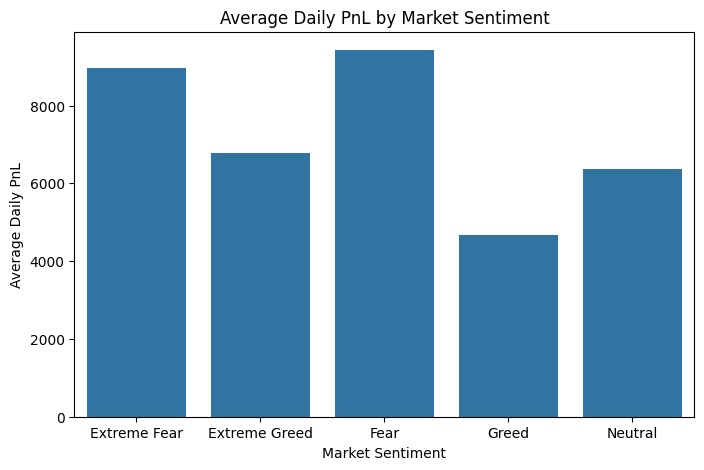

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sentiment_pnl,
    x='classification',
    y='daily_pnl'
)

plt.title('Average Daily PnL by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Daily PnL')

plt.show()

**Interpretation**

Trader profitability was highest during Fear and Extreme Fear periods, while Greed periods showed comparatively lower average daily profitability.

This suggests that traders may have performed better during cautious market conditions, potentially due to more disciplined positioning or stronger mean-reversion opportunities during fearful market environments.

### Win Rate by Sentiment

Analyzing whether trader consistency changes under different market sentiment conditions.

In [31]:
sentiment_winrate = daily_metrics.groupby(
    'classification'
)['win_rate'].mean().reset_index()

sentiment_winrate

,classification,win_rate
0,Extreme Fear,0.334765
1,Extreme Greed,0.389560
2,Fear,0.381793
3,Greed,0.311985
4,Neutral,0.345074


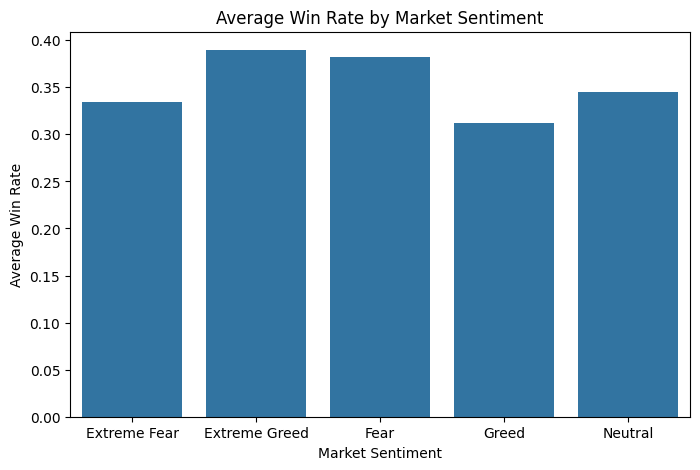

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sentiment_winrate,
    x='classification',
    y='win_rate'
)

plt.title('Average Win Rate by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Win Rate')

plt.show()

**Interpretation**

Trader win rates were highest during Extreme Greed and Fear periods, while standard Greed periods showed the weakest trading consistency.

This may indicate that highly optimistic market conditions encouraged more aggressive or less selective trading behavior, reducing overall execution quality.

### Trading Activity by Sentiment

Analyzing whether trader participation and trading frequency change across sentiment conditions.

In [33]:
sentiment_trades = daily_metrics.groupby(
    'classification'
)['trade_count'].mean().reset_index()

sentiment_trades

,classification,trade_count
0,Extreme Fear,47.100000
1,Extreme Greed,42.393013
2,Fear,65.402062
3,Greed,50.690402
4,Neutral,67.496774


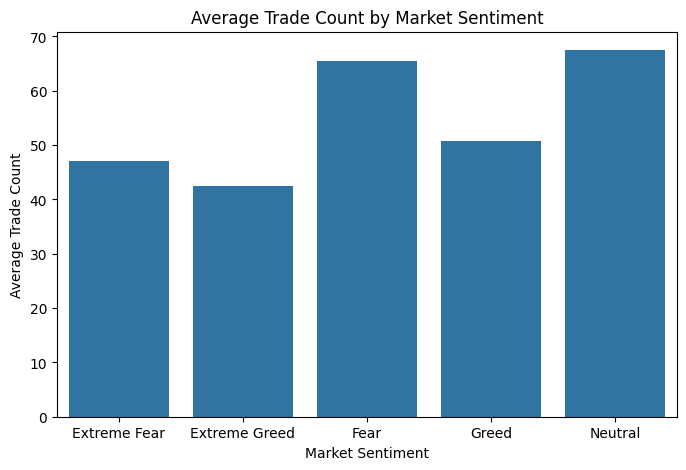

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sentiment_trades,
    x='classification',
    y='trade_count'
)

plt.title('Average Trade Count by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Trade Count')

plt.show()

**Interpretation**

Trading activity was highest during Neutral and Fear market conditions, while Extreme Greed periods showed relatively lower trading frequency.

This suggests that traders may have traded more actively during uncertain or corrective market phases rather than during euphoric market conditions.


### Average Trade Size by Sentiment

Analyzing whether traders increase or reduce position sizes under different sentiment conditions.

In [35]:
sentiment_size = daily_metrics.groupby(
    'classification'
)['avg_trade_size'].mean().reset_index()

sentiment_size

,classification,avg_trade_size
0,Extreme Fear,9761.140240
1,Extreme Greed,9083.458016
2,Fear,10765.409176
3,Greed,10269.311920
4,Neutral,10442.616840


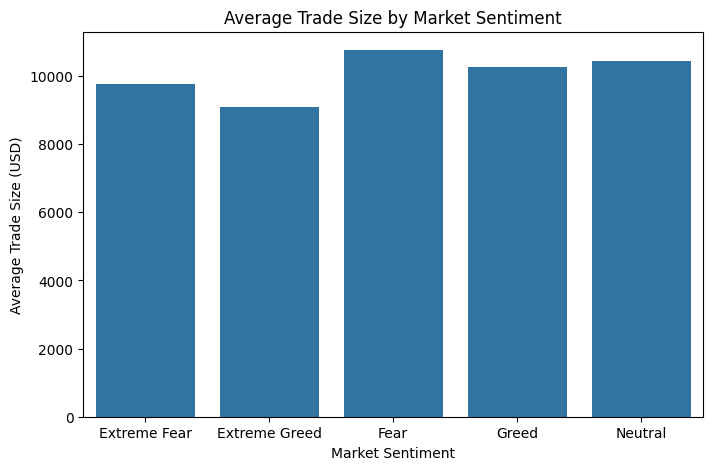

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sentiment_size,
    x='classification',
    y='avg_trade_size'
)

plt.title('Average Trade Size by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Trade Size (USD)')

plt.show()

**Interpretation**

Average trade sizes were largest during Fear conditions and smallest during Extreme Greed periods.

This indicates that traders may have taken larger positions during fearful markets, potentially attempting to capitalize on perceived undervaluation or recovery opportunities.

### Long/Short Bias by Sentiment

Analyzing directional trading behavior across different market sentiment conditions.

In [37]:
sentiment_long = daily_metrics.groupby(
    'classification'
)['long_ratio'].mean().reset_index()

sentiment_long

,classification,long_ratio
0,Extreme Fear,0.623528
1,Extreme Greed,0.514939
2,Fear,0.593789
3,Greed,0.494259
4,Neutral,0.519456


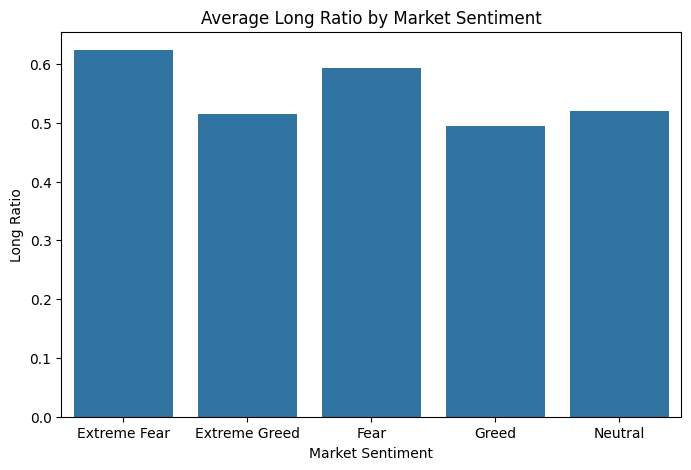

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sentiment_long,
    x='classification',
    y='long_ratio'
)

plt.title('Average Long Ratio by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Long Ratio')

plt.show()

**Interpretation**

Long positioning was highest during Fear and Extreme Fear periods, while Greed conditions showed relatively balanced positioning between long and short trades.

This may suggest that traders attempted to accumulate long positions during fearful markets in anticipation of potential rebounds.

### Profitability Distribution by Sentiment

Analyzing the spread and variability of trader profitability across different market sentiment conditions.

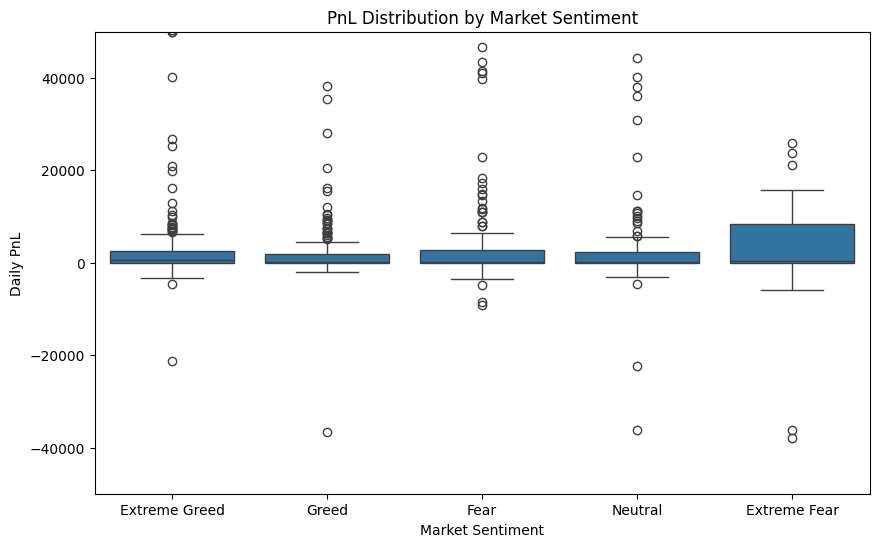

In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=daily_metrics,
    x='classification',
    y='daily_pnl'
)

plt.ylim(-50000, 50000)

plt.title('PnL Distribution by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Daily PnL')

plt.show()

**Interpretation**

The PnL distribution across all sentiment conditions is highly dispersed, with several extreme positive and negative outliers visible.

Most trader-day profitability values are concentrated near lower PnL ranges, while a small number of traders generated exceptionally large gains or losses. This suggests that trading outcomes were heavily skewed and that a minority of traders contributed disproportionately to overall profitability volatility.

The presence of large outliers across multiple sentiment regimes also indicates elevated market risk and inconsistent trader performance.

## Trader Segmentation Analysis

This section analyzes how different categories of traders behave and perform under varying market sentiment conditions.

The goal is to identify whether certain trader groups demonstrate stronger profitability, consistency, or risk-taking behavior.

### High Activity vs Low Activity Traders

Comparing profitability and trading behavior between highly active traders and less active traders.

In [41]:
activity_summary = daily_metrics.groupby(
    'trader_activity'
)[[
    'daily_pnl',
    'win_rate',
    'avg_trade_size',
    'trade_count'
]].mean().reset_index()

activity_summary

,trader_activity,daily_pnl,win_rate,avg_trade_size,trade_count
0,High Activity,11618.486931,0.438717,9447.110312,100.624733
1,Low Activity,1662.452708,0.265185,10728.698092,8.309322


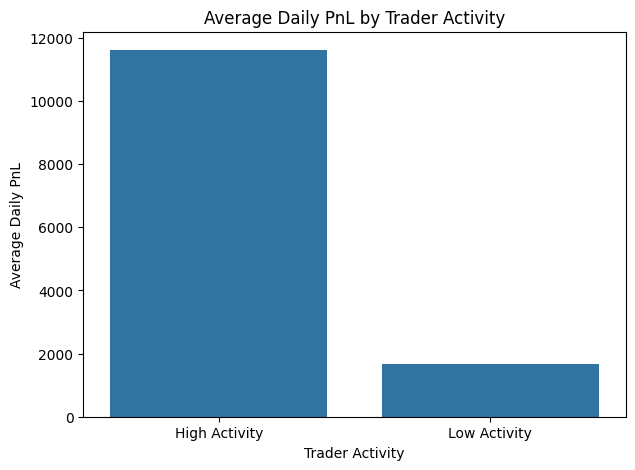

In [42]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=activity_summary,
    x='trader_activity',
    y='daily_pnl'
)

plt.title('Average Daily PnL by Trader Activity')
plt.xlabel('Trader Activity')
plt.ylabel('Average Daily PnL')

plt.show()

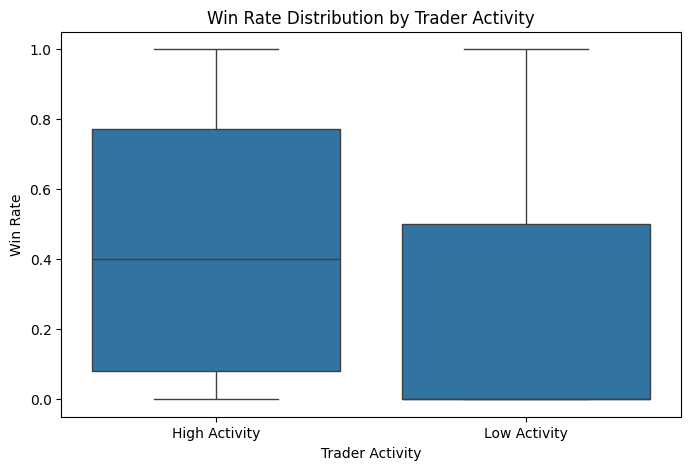

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=daily_metrics,
    x='trader_activity',
    y='win_rate'
)

plt.title('Win Rate Distribution by Trader Activity')
plt.xlabel('Trader Activity')
plt.ylabel('Win Rate')

plt.show()

**Interpretation**

High-activity traders significantly outperformed low-activity traders across both profitability and win rate metrics.

Although low-activity traders executed larger average trade sizes, they achieved substantially lower profitability and weaker trading consistency. In contrast, high-activity traders maintained smaller average position sizes while generating higher daily profitability and stronger win rates.

This suggests that more active traders may have benefited from better execution, improved market adaptability, or more effective risk distribution across multiple trades.

### Profitable vs Non-Profitable Traders

Comparing behavioral characteristics between profitable and non-profitable trader groups.

In [45]:
pnl_summary = daily_metrics.groupby(
    'pnl_category'
)[[
    'trade_count',
    'avg_trade_size',
    'long_ratio',
    'win_rate'
]].mean().reset_index()

pnl_summary

,pnl_category,trade_count,avg_trade_size,long_ratio,win_rate
0,Non-Profitable,30.223325,8600.283434,0.591530,0.017566
1,Profitable,72.369888,11205.810430,0.482958,0.601945


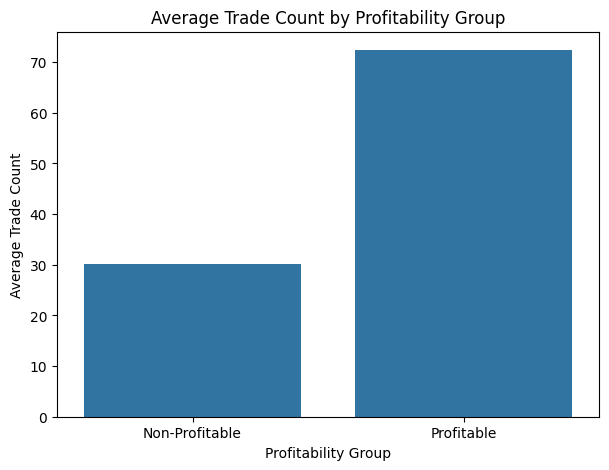

In [46]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=pnl_summary,
    x='pnl_category',
    y='trade_count'
)

plt.title('Average Trade Count by Profitability Group')
plt.xlabel('Profitability Group')
plt.ylabel('Average Trade Count')

plt.show()

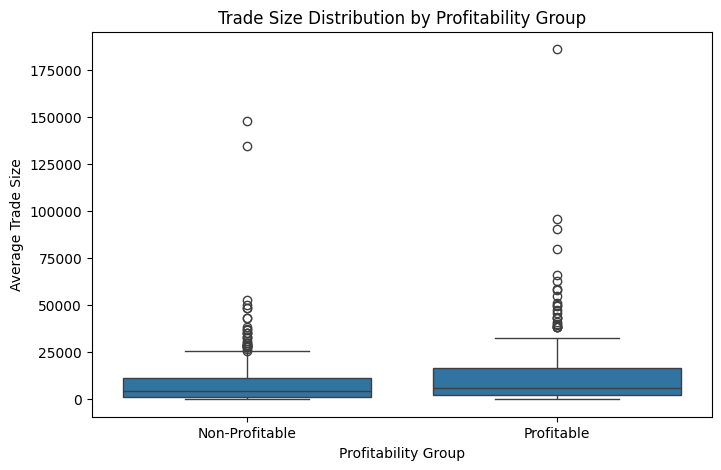

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=daily_metrics,
    x='pnl_category',
    y='avg_trade_size'
)

plt.title('Trade Size Distribution by Profitability Group')
plt.xlabel('Profitability Group')
plt.ylabel('Average Trade Size')

plt.show()

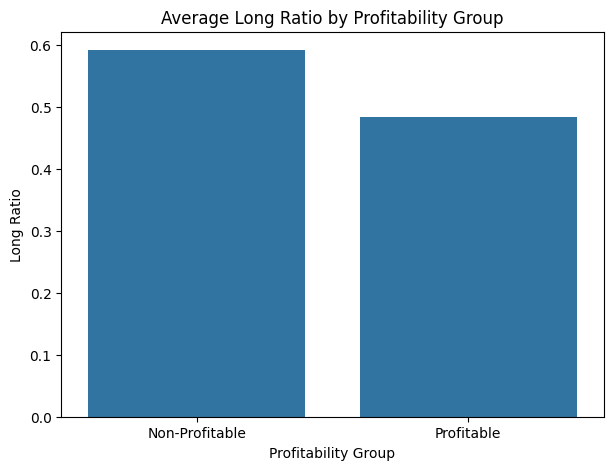

In [48]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=pnl_summary,
    x='pnl_category',
    y='long_ratio'
)

plt.title('Average Long Ratio by Profitability Group')
plt.xlabel('Profitability Group')
plt.ylabel('Long Ratio')

plt.show()

**Interpretation**

Profitable traders demonstrated substantially higher trading activity, larger average trade sizes, and significantly stronger win rates compared to non-profitable traders.

Non-profitable traders showed a noticeably stronger long bias, while profitable traders maintained more balanced directional positioning. This suggests that excessive directional conviction may have negatively impacted trading performance.

The findings indicate that successful traders combined higher participation with stronger execution quality and more balanced market exposure.

### Long-Biased vs Short-Biased Traders

Classifying traders based on directional positioning behavior.

In [49]:
daily_metrics['position_bias'] = np.where(
    daily_metrics['long_ratio'] > 0.5,
    'Long-Biased',
    'Short-Biased'
)

In [50]:
bias_summary = daily_metrics.groupby(
    'position_bias'
)[[
    'daily_pnl',
    'win_rate',
    'avg_trade_size'
]].mean().reset_index()

bias_summary

,position_bias,daily_pnl,win_rate,avg_trade_size
0,Long-Biased,5155.624235,0.292440,10520.531629
1,Short-Biased,8248.030597,0.417136,9614.088615


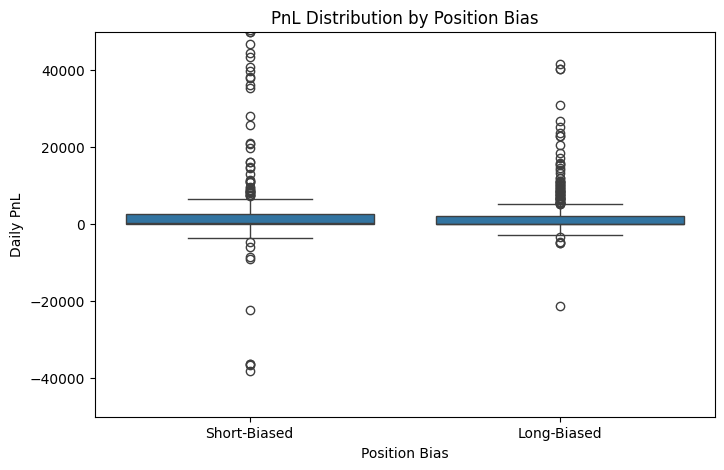

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=daily_metrics,
    x='position_bias',
    y='daily_pnl'
)

plt.title('PnL Distribution by Position Bias')
plt.xlabel('Position Bias')
plt.ylabel('Daily PnL')

plt.ylim(-50000, 50000)

plt.show()

**Interpretation**

Short-biased traders achieved higher average profitability and stronger win rates compared to long-biased traders.

Although long-biased traders traded with slightly larger average position sizes, they generated weaker overall performance and lower trading consistency.

This suggests that maintaining excessive long exposure may have reduced trading effectiveness during the analyzed market conditions, while more defensive or bearish positioning appeared comparatively more effective.

## Key Insights & Findings

This section summarizes the major behavioral and performance patterns identified during the analysis of trader activity and market sentiment conditions.

### Insight 1 — Traders Performed Better During Fear Conditions

Average daily profitability was highest during Fear and Extreme Fear market conditions, with Fear periods generating average daily PnL above 9,400 compared to approximately 4,600 during Greed periods.

Additionally, Fear conditions showed larger average trade sizes and wider profitability distributions, indicating increased market volatility and stronger trading opportunities during cautious market environments.

This suggests that traders may have benefited from heightened price movements and recovery opportunities during fearful market conditions.

### Insight 2 — High Activity Traders Demonstrated Stronger Performance

High-activity traders significantly outperformed low-activity traders across both profitability and consistency metrics.

Highly active traders achieved average daily profitability above 11,600 with a win rate of approximately 44%, compared to only 1,600 average daily profitability and 26% win rate for low-activity traders.

Interestingly, high-activity traders used smaller average trade sizes, suggesting that stronger execution and diversified participation may have contributed more to profitability than aggressive position sizing alone.

### Insight 3 — Strong Long Bias Was Linked to Lower Performance

Non-profitable traders exhibited a noticeably stronger long bias compared to profitable traders.

While long positioning increased during Fear and Extreme Fear conditions, traders with excessive long exposure achieved lower profitability and weaker win rates overall.

In contrast, short-biased traders generated higher average profitability and stronger trading consistency, suggesting that more balanced or defensive positioning strategies may have been more effective during the analyzed market conditions.

### Insight 4 — Trader Profitability Was Highly Concentrated

The profitability distribution analysis revealed substantial dispersion across all market sentiment conditions, with multiple extreme positive and negative outliers.

Most trader-day profitability values remained concentrated near lower pnl ranges, while a relatively small subset of traders generated disproportionately large profits or losses.

This indicates that trading performance was highly uneven and that a minority of traders contributed significantly to overall market profitability volatility.

### Insight 5 — Market Sentiment Influenced Trader Behavior

Trader behavior varied noticeably across sentiment regimes.

Fear conditions were associated with:
- larger average trade sizes
- stronger long positioning
- higher trading activity

Meanwhile, Greed conditions showed comparatively lower profitability and weaker trading consistency.

These behavioral shifts suggest that trader psychology and market sentiment significantly influenced trading decisions, positioning behavior, and overall market participation.

## Strategy Recommendations

Based on the behavioral and performance analysis, the following strategy recommendations are proposed to improve trader decision-making and risk management under different market sentiment conditions.

### Recommendation 1 — Reduce Directional Bias During Fear Conditions

The analysis showed that traders increased long positioning significantly during Fear and Extreme Fear market conditions. However, traders with excessive long exposure generally demonstrated weaker profitability and lower win rates compared to more balanced or short-biased traders.

To improve trading consistency, traders should avoid overcommitting to directional long exposure during fearful market environments and instead maintain more balanced positioning strategies with tighter risk controls.

### Recommendation 2 — Favor Consistent Participation Over Large Position Sizing

High-activity traders achieved substantially stronger profitability and higher win rates despite using smaller average trade sizes compared to low-activity traders.

This suggests that consistent market participation, diversified execution, and controlled position sizing may be more effective than infrequent large trades. Traders should prioritize disciplined execution and gradual exposure management rather than relying on oversized positions.

These recommendations are intended as behavioral risk-management guidelines derived from historical trading and sentiment patterns observed in the dataset.

## Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader behavior on Hyperliquid using historical trading activity and Fear/Greed sentiment data.

The findings showed that market sentiment influenced both trader performance and trading behavior. Fear and Extreme Fear conditions were associated with higher average profitability, larger trade sizes, and stronger long positioning, while Greed periods generally showed lower profitability and weaker trading consistency.

Trader segmentation analysis further revealed that high-activity traders significantly outperformed low-activity traders, and that excessive long bias was associated with weaker overall performance.

Overall, the results suggest that market psychology plays an important role in shaping trading decisions, risk exposure, and profitability outcomes in crypto trading environments.